In [1]:
%load_ext autoreload
%autoreload 2

import rootutils
rootutils.setup_root('.', dotenv=True, pythonpath=True, cwd=True)

PosixPath('/home/milton/workspace/ocdm')

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
import csv
from pathlib import Path

import torch
from scripts.common import load_model, load_dataset
from scripts.vlm_eval import query_vlm_batch, load_vlm, tensor_to_pil, get_shape_name, build_prompt_template, sample_shape_examples, compose_example_grid
device = torch.device('cuda')  if  torch.cuda.is_available() else torch.device('cpu')

In [3]:
vlm_model: str = 'google/siglip2-so400m-patch14-384'
vlm, processor = load_vlm(vlm_model, device, compile=False)

# dSprites

In [4]:
dataset_name = 'dsprites'
filter_expr = "( shape == 3 ) & ( posX < 0.5 )"
batch_size = 1

train_dataset, test_dataset, train_loader, test_loader = load_dataset(dataset_name, filter_expr, batch_size)
build_prompt = build_prompt_template(dataset_name, 'orientation')

In [4]:
# model_name = 'vae'
# model_checkpoint = Path('data/results/figure1/combgen_dsprites_heart_position_vae_on:2025-11-12_13-45/epoch=490-step=471360.ckpt')

# model_name = 'wae'
# model_checkpoint = Path("data/results/figure1/combgen_dsprites_heart_position_wae_on:2025-11-20_09-21/epoch=357-step=343680.ckpt")

model_name = 'sa1'
model_checkpoint = Path("data/results/figure1/combgen_dsprites_heart_position_sa_on:2025-11-19_19-16/epoch=517-step=497280.ckpt")

model, device = load_model(model_name, model_checkpoint, compile=False)
print(model)

OptimizedModule(
  (_orig_mod): FigureGroundAutoencoder(
    (encoder): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Permute(0,2,3,1)
      (7): PositionEmbedding2D(height=8, width=8)
      (8): Flatten(start_dim=1, end_dim=2)
      (9): LayerNorm((np.int64(64), np.int64(64)), eps=1e-05, elementwise_affine=True)
      (10): Linear(in_features=64, out_features=64, bias=True)
      (11): ReLU()
    )
    (fig_rep): FigureGroundSegmentation(latent_size=64, n_iter=3)
    (decoder): Sequential(
      (0): SpatialBroadcast(height=8,width=8, input_last=True)
      (1): PositionEmbedding2D(height=8, width=8)
      (2): Permute(0,3,1,2)
      (3): ConvTranspose2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): ReLU(

In [55]:
dataset_name = 'dsprites'
filter_expr = "( shape == 3 ) & ( orientation < np.pi )"
batch_size = 1

train_dataset, test_dataset, train_loader, test_loader = load_dataset(dataset_name, filter_expr, batch_size)
build_prompt = build_prompt_template(dataset_name, 'orientation')

In [56]:
model_name = 'sa1'
model_checkpoint = Path("data/results/figure1/combgen_dsprites_heart_rotation_sa_on:2025-11-12_19-42/epoch=510-step=490560.ckpt")

model_name = 'sa1'
model_checkpoint = Path("data/results/figure1/combgen_dsprites_heart_rotation_sa_on:2025-11-12_19-42/epoch=510-step=490560.ckpt")

model, device = load_model(model_name, model_checkpoint, compile=False)
print(model)

OptimizedModule(
  (_orig_mod): FigureGroundAutoencoder(
    (encoder): Sequential(
      (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (5): ReLU()
      (6): Permute(0,2,3,1)
      (7): PositionEmbedding2D(height=8, width=8)
      (8): Flatten(start_dim=1, end_dim=2)
      (9): LayerNorm((np.int64(64), np.int64(64)), eps=1e-05, elementwise_affine=True)
      (10): Linear(in_features=64, out_features=64, bias=True)
      (11): ReLU()
    )
    (fig_rep): FigureGroundSegmentation(latent_size=16, n_iter=3)
    (decoder): Sequential(
      (0): SpatialBroadcast(height=8,width=8, input_last=True)
      (1): PositionEmbedding2D(height=8, width=8)
      (2): Permute(0,3,1,2)
      (3): ConvTranspose2d(16, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): ReLU(

In [13]:
vlm_model: str = 'google/siglip2-so400m-patch14-384'
vlm, processor = load_vlm(vlm_model, device, compile=False)

In [57]:
df = pl.read_csv(model_checkpoint.parent / "vlm_eval_detail.csv")
df.head()

split,sample_idx,shape,factor_value,prompt,response,answer
str,i64,str,f64,str,str,str
"""train""",0,"""square""",0.0,"""Is this a square with orientat…","""Yes.""","""yes"""
"""train""",1,"""square""",0.0,"""Is this a square with orientat…","""Yes.""","""yes"""
"""train""",2,"""square""",0.0,"""Is this a square with orientat…","""Yes.""","""yes"""
"""train""",3,"""square""",0.0,"""Is this a square with orientat…","""Yes.""","""yes"""
"""train""",4,"""square""",0.0,"""Is this a square with orientat…","""Yes.""","""yes"""


In [58]:
df.filter(pl.col("answer") == "no")

split,sample_idx,shape,factor_value,prompt,response,answer
str,i64,str,f64,str,str,str
"""train""",10,"""square""",0.0,"""Is this a square with orientat…","""No.""","""no"""
"""train""",11,"""square""",0.0,"""Is this a square with orientat…","""No.""","""no"""
"""train""",12,"""square""",0.0,"""Is this a square with orientat…","""No.""","""no"""
"""train""",44,"""square""",0.0,"""Is this a square with orientat…","""No.""","""no"""
"""train""",108,"""square""",0.0,"""Is this a square with orientat…","""No.""","""no"""
…,…,…,…,…,…,…
"""test""",122875,"""heart""",3.061039,"""Is this a heart with orientati…","""No.""","""no"""
"""test""",122876,"""heart""",3.061039,"""Is this a heart with orientati…","""No.""","""no"""
"""test""",122877,"""heart""",3.061039,"""Is this a heart with orientati…","""No.""","""no"""


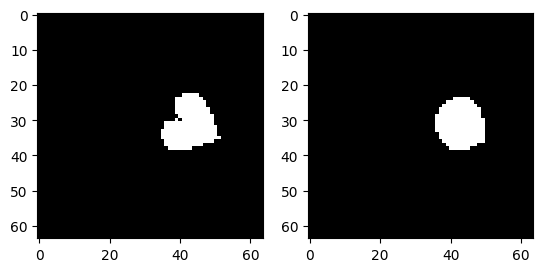

In [72]:
# idx = 0
# idx = 1047
idx = 90_000
x, _ = test_dataset[idx]
r = model.reconstruction(x[None].to(device))[0].cpu()
# x = torch.tile(x, (3, 1, 1))
o_img = tensor_to_pil(x)
r_img = tensor_to_pil(r > 0.5)
_, (axi, axr) = plt.subplots(ncols=2)
axi.imshow(o_img);
axr.imshow(r_img);

In [73]:
prompt = build_prompt("heart", 5.316541)
print(prompt)

A rotated white heart on a black background.


In [74]:
query_vlm_batch([r_img], [prompt], vlm, processor, device)

(tensor([[False]], device='cuda:0'), tensor([[0.0461]], device='cuda:0'))

# Pentominos

In [19]:
filter_expr = "np.isin( shape , [1, 3, 5, 8] ) & ( angle >= 180 )"
batch_size = 1

dataset_name = 'pentominos'
train_dataset, test_dataset, train_loader, test_loader = load_dataset(dataset_name, filter_expr, batch_size)
train_dataset.shape_names

array(['I', 'F', 'L', 'P', 'N', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'],
      dtype='<U1')

In [78]:
model_name = "vae"
model_checkpoint = Path("data/results/figure2/combgen_pentominos_w_rotation_vae_on:2025-12-11_14-09/epoch=394-step=493750.ckpt")
vae, device = load_model(model_name, model_checkpoint, compile=False)
vae = vae.cpu()

model_name = "wae"
model_checkpoint = Path("data/results/figure2/combgen_pentominos_w_rotation_wae_on:2025-12-11_16-16/epoch=390-step=488750.ckpt")
wae, device = load_model(model_name, model_checkpoint, compile=False)
wae = wae.cpu()

model_name = "sa1"
model_checkpoint = Path("data/results/figure2/combgen_pentominos_rotation_sa_on:2026-03-07_22-58/epoch=399-step=500000.ckpt")
sa1, device = load_model(model_name, model_checkpoint, compile=False)
sa1 = sa1.cpu()

In [172]:
idx = 300_000
img, _ = train_dataset[idx]
fv = train_dataset.factor_values[idx]
sv, rv = int(fv[0]), fv[3]
shape_name = get_shape_name(train_dataset, sv)

print(shape_name, fv)

N [  4.        0.        2.625   276.92307 -10.      -10.     ]


In [155]:
def build_prompt_template(dataset, query_factor, n_examples=0):
    if dataset == 'dsprites':
        template = "A {rotated} white {shape_name} on a black background."
        def prompt_builder(shape_name, orientation, **kwargs):
            return template.format(
                shape_name=shape_name,
                rotated="rotated" if orientation > 0.45 or orientation > 5.9 else ""  # radians
            )
    elif dataset == "shapes3d":
        template = "A scene with a {color} colored {shape_name} at the center."
        def prompt_builder(shape_name, color, **kwargs):
            return template.format( shape_name=shape_name, color=color)
    elif dataset == 'pentominos':
        if n_examples > 0:
            def prompt_builder(shape_name, angle, **kwargs):
                return (
                    # f"The {n_examples} leftmost white shapes on a black background are rotated examples of the {shape_name} pentomino. "
                    # f"Is the rightmost white shape on a black background also an example of a rotated {shape_name} pentomino?"
                    "The white shape on a black background on the right of the image is of the same type as the white shape on a black background on the left."
                )
        else:
            template = "A {rotated} white {shape_name} on a black background."
            def prompt_builder(shape_name, angle, **kwargs):
                return template.format(
                    shape_name=shape_name,
                    rotated="rotated" if angle > 20 or angle < 340 else ""
                )
    else:
        raise RuntimeError("Unrecognized dataset")

    return prompt_builder


In [156]:
n_examples = 1
build_prompt = build_prompt_template(dataset_name, 'angle', n_examples=n_examples)
examples = sample_shape_examples(train_dataset, n_per_shape=n_examples, seed=100)

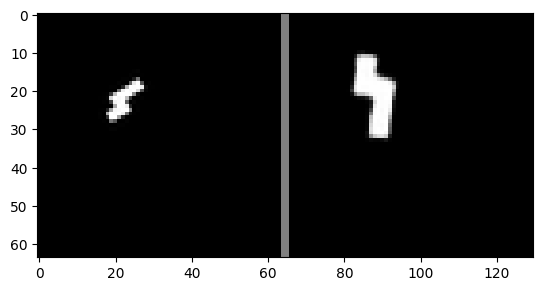

In [178]:
r = sa1.reconstruction(img[None])[0]
# r = vae.reconstruction(img[None])[0]
# r = wae.reconstruction(img[None])[0]

# test_image = tensor_to_pil(img)
test_image = tensor_to_pil(r)
z_examples = compose_example_grid(examples[shape_name], test_image=test_image)

plt.imshow(z_examples)

In [159]:
prompt = build_prompt(shape_name, rv)
print(prompt)
query_vlm_batch(z_examples, prompt, vlm, processor, device)

The white shape on a black background on the right of the image is of the same type as the white shape on a black background on the left.


(tensor([[True]], device='cuda:0'), tensor([[0.9921]], device='cuda:0'))

## Preference metric

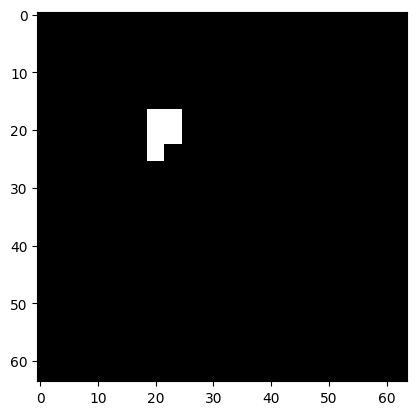

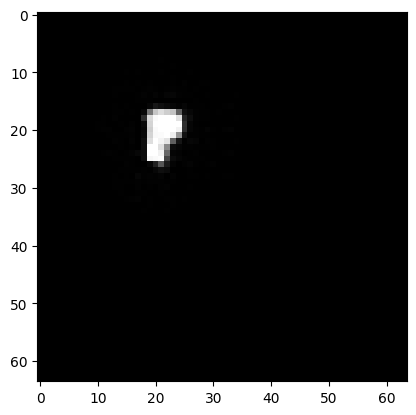

In [171]:
plt.imshow(tensor_to_pil(img))
plt.show()
plt.imshow(tensor_to_pil(r))

In [174]:
inputs = processor(images=tensor_to_pil(img), return_tensors="pt").to(device)
gt_features = vlm.get_image_features(**inputs)
gt_features = gt_features / gt_features.norm(dim=-1, keepdim=True)

In [177]:
inputs = processor(images=tensor_to_pil(r), return_tensors="pt").to(device)
r_features = vlm.get_image_features(**inputs)
r_features = r_features / r_features.norm(dim=-1, keepdim=True)
sim = gt_features @ r_features.T
print(sim)

tensor([[0.9469]], device='cuda:0')


In [175]:
inputs = processor(images=tensor_to_pil(r), return_tensors="pt").to(device)
r_features = vlm.get_image_features(**inputs)
r_features = r_features / r_features.norm(dim=-1, keepdim=True)
sim = gt_features @ r_features.T
print(sim)

tensor([[0.9548]], device='cuda:0')


In [179]:
inputs = processor(images=tensor_to_pil(r), return_tensors="pt").to(device)
r_features = vlm.get_image_features(**inputs)
r_features = r_features / r_features.norm(dim=-1, keepdim=True)
sim = gt_features @ r_features.T
print(sim)

tensor([[0.9739]], device='cuda:0')
